In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## LOAD DATASET

In [3]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
import torch.nn as nn
from src.CHM.test import test_zsl_cbm_classifier
from src.utils.plot import plot_zsl_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

AllenNLP not available. Registrable won't work.


In [4]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset, concept2id, id2concept = load_concept_data('../../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
datasetClasses = prepare_class_concept_dataset(class_concept_matrix, class2id)

In [5]:
from src.utils.dataset import zsl_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset

features_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'
test_path = '../../AwA2_Dataset_Labels/Animals_with_Attributes2/zsl/testclasses.txt'
trainval_path = '../../AwA2_Dataset_Labels/Animals_with_Attributes2/zsl/trainvalclasses.txt'
classes_path = '../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'

(X_train, y_train), (X_test, y_test) = zsl_split_awa2_features(
    features_path, labels_path, classes_path, trainval_path, test_path
)

#(X_train, y_train), (X_test, y_test), (X_val, y_val) = zsl_split_awa2_features(
#    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
#)

BATCH_SIZE = 32
EPOCHS = 6
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
#val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
#val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento in corso... (potrebbe richiedere qualche secondo)
Dimensioni totali feature: (37322, 2048)
Training set: 29409 samples (40 classi)
Test set: 7913 samples (10 classi)
Using device: cpu


In [6]:
test_ids = set(y_test)
print(test_ids)

{np.int64(34), np.int64(7), np.int64(9), np.int64(41), np.int64(47), np.int64(50), np.int64(23), np.int64(24), np.int64(30), np.int64(31)}


## BOX

In [7]:
from src.BOX.model import BoxHierarchyModelJoint
from src.utils.box import get_geometric_class_weights

BOX_DIM = 16

info = 'dynamic_box'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

box_model = BoxHierarchyModelJoint(num_concepts=len(concepts), num_classes=len(classes), dim=BOX_DIM)
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia_joint.pth"))
W_geom = get_geometric_class_weights(box_model, len(classes), len(concepts), device)

## CONCEPT PREDICTOR

In [8]:
from src.CP.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [9]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    None, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 2.7115 | Acc: 97.0166 
Loss: 1.6470 | Acc: 98.1481 
Loss: 1.4282 | Acc: 98.3776 
Loss: 1.2953 | Acc: 98.5253 
Loss: 1.2012 | Acc: 98.6315 
Loss: 1.1333 | Acc: 98.7108 


## GEOMETRIC CLASSIFIER

In [10]:
concept_weights = box_model.concept_embeddings.weight
class_weights = box_model.class_embeddings.weight
info = 'dynamic_box'
db_model = ConceptBottleneckClassifier(
        num_concepts=len(concepts), 
        box_dim=BOX_DIM, 
        num_classes=len(classes), 
        info=info, 
        concept_embeddings=concept_weights,
        class_embeddings=class_weights
)
info = 'geometric'
g_model = ConceptBottleneckClassifier(
        num_concepts=len(concepts), 
        num_classes=len(classes), 
        box_dim=BOX_DIM, 
        info=info, 
        geometric_weights=W_geom
)

In [11]:
box_tensors = None
unseen_idx_list = [i - 1 for i in test_ids]
db_accuracy, db_preds, db_labels, db_concepts_preds, db_concepts_truth, db_concepts_probs = test_zsl_cbm_classifier(
     model=db_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     unseen_classes_idx=unseen_idx_list
)

Inizio valutazione Zero-Shot (SZSL) sul Test Set...

Accuratezza ZSL Totale: 42.51%


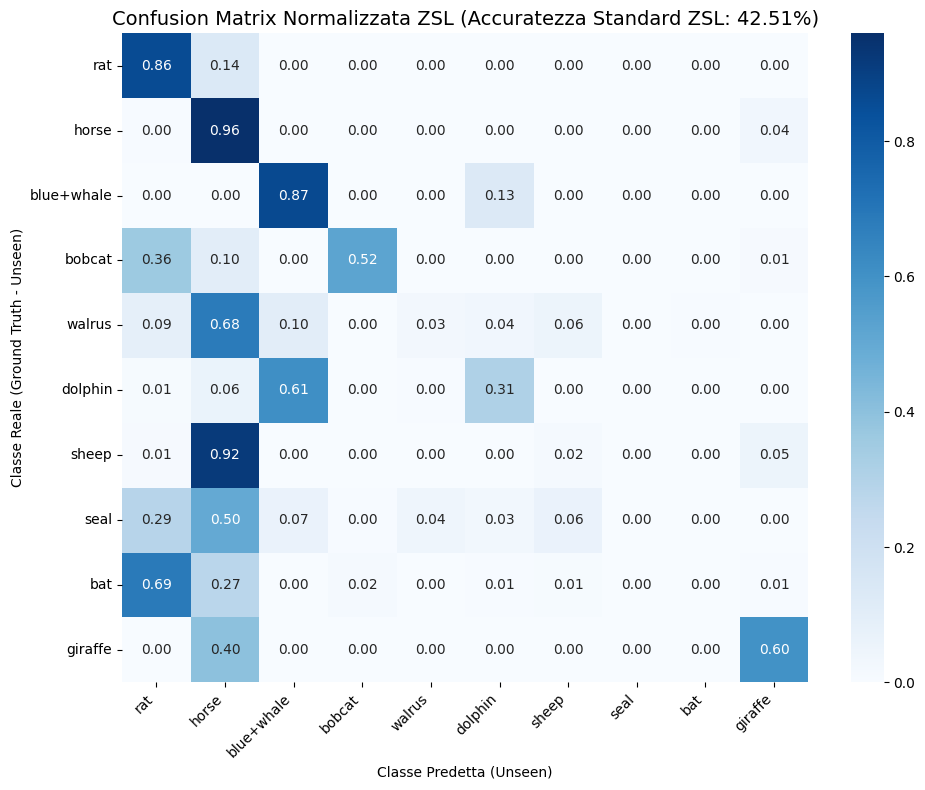


Analisi degli Errori Principali nel Test Set Zero-Shot:
 - 1305 volte: 'sheep' è stato scambiato per 'horse'
 - 577 volte: 'dolphin' è stato scambiato per 'blue+whale'
 - 496 volte: 'seal' è stato scambiato per 'horse'
 - 481 volte: 'giraffe' è stato scambiato per 'horse'
 - 285 volte: 'seal' è stato scambiato per 'rat'


In [12]:
plot_zsl_test_results(db_accuracy, db_preds, db_labels, unseen_idx_list, class_names=classes)

In [13]:
box_tensors = None
unseen_idx_list = [i - 1 for i in test_ids]
g_accuracy, g_preds, g_labels, g_concepts_preds, g_concepts_truth, g_concepts_probs = test_zsl_cbm_classifier(
     model=g_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     unseen_classes_idx=unseen_idx_list
)

Inizio valutazione Zero-Shot (SZSL) sul Test Set...

Accuratezza ZSL Totale: 36.71%


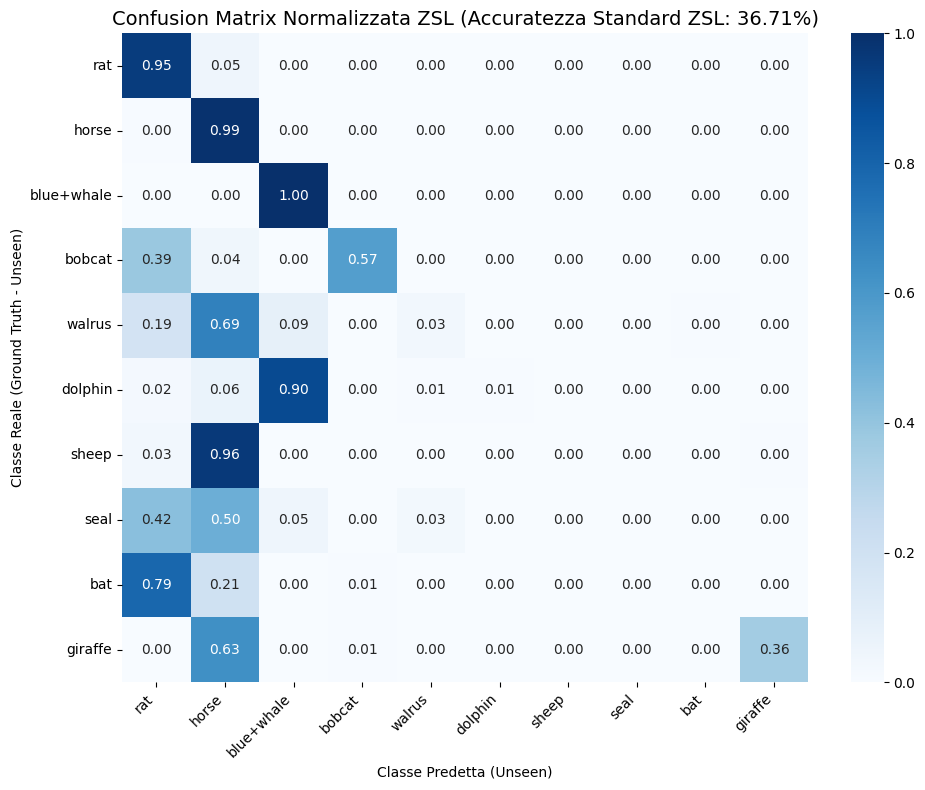


Analisi degli Errori Principali nel Test Set Zero-Shot:
 - 1367 volte: 'sheep' è stato scambiato per 'horse'
 - 852 volte: 'dolphin' è stato scambiato per 'blue+whale'
 - 759 volte: 'giraffe' è stato scambiato per 'horse'
 - 493 volte: 'seal' è stato scambiato per 'horse'
 - 419 volte: 'seal' è stato scambiato per 'rat'


In [14]:
plot_zsl_test_results(g_accuracy, g_preds, g_labels, unseen_idx_list, class_names=classes)